# Tutorial 7: Designing a CPW resonator to match targets

In this tutorial you will learn how to design a circuit-level model distributed element in order to meet design targets.

For this tutorial, we will  use the design targets of readout frequency $f_r$ and quality factor $Q$.
In order to meet these targets we will vary the resonator length
$d$ and the coupling capacitor $C_c$, in the case of symmetric coupling on both sides.

This is shown for the purposes of demonstration, but the processes shown in this tutorial can be used to
perform sweeps for various circuit and geometric parameters to target certain specs. 


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl

sl.apply_style()


## Setup


First we define our CPW and choose what LOM model to use.


In [3]:
cpw = sl.CPWParams(ep_r=11.45)
freq = rf.Frequency(4e9, 12e9, 8001, unit="Hz")
MODEL = "optimized"                               # or "foster" / "analytical"


We will now define the target $f_0$ and $Q$ for our resonator. Here, our target $f_0 = 7 \text{GHz}$ and our target $Q=8000$.


In [4]:
target_Q = 8000
target_f = 7.0


In this tutorial we will match the design to these targets by first picking $d$ to match the target frequency, then picking $C_c$ for the
quality factor.


## 1. Matching circuit parameters to design targets


### 1a. Map length to frequency

First we sweep the resonator length and measure $f_0$ at a fixed reference coupling. The
relationship is smooth and monotonic, so we can interpolate it to solve for the
length that hits a target frequency.


In [5]:
d_values = np.linspace(5.5e-3, 9.0e-3, 8)
f_of_d = np.array([sl.extract_f0_kappa(cpw, d=d, Cc=6e-15)[0] / 1e9 for d in d_values])

for d, f in zip(d_values, f_of_d):
    print("d = {:.2f} mm    f0 = {:.4f} GHz".format(d * 1e3, f))


d = 5.50 mm    f0 = 10.5807 GHz
d = 6.00 mm    f0 = 9.7244 GHz
d = 6.50 mm    f0 = 8.9963 GHz
d = 7.00 mm    f0 = 8.3697 GHz
d = 7.50 mm    f0 = 7.8246 GHz
d = 8.00 mm    f0 = 7.3463 GHz
d = 8.50 mm    f0 = 6.9230 GHz
d = 9.00 mm    f0 = 6.5459 GHz


target f_r = 7.00 GHz  ->  d = 8.409 mm


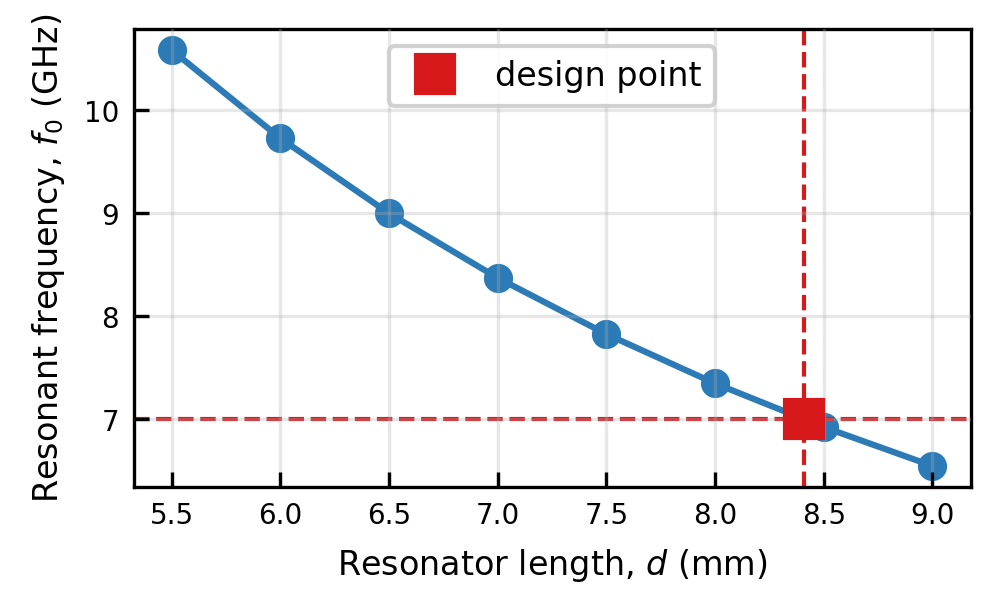

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Resonator length, $d$ (mm)', ylabel='Resonant frequency, $f_0$ (GHz)'>)

In [6]:
d_star = sl.invert_monotonic(d_values, f_of_d, target_f)
print("target f_r = {:.2f} GHz  ->  d = {:.3f} mm".format(target_f, d_star * 1e3))

sl.plot_curves(
    d_values * 1e3, f_of_d,
    xlabel=sl.LABEL_LENGTH,
    ylabel=sl.LABEL_F0,
    fmt="o-",
    color=sl.COLOR_PRIMARY,
    hline=target_f,
    vline=d_star * 1e3,
    point=(d_star * 1e3, target_f),
)


### 1b. At that length, map coupling to quality factor

Now fix $d = d^\star$ and sweep the coupling capacitor. We need the lumped `L`, `C`
at this length (for the $Q$ bookkeeping), which one `fit_lom` call provides
(default model: optimized).

> **Note on loss:** These chips are lossless, so the achieved $Q$ is the coupling $Q_c$.
>  With a finite internal $Q_i$, design $Q_c$ to a target loaded
>  $Q_\ell^{-1} = Q_c^{-1} + Q_i^{-1}$.


In [7]:
L_star, C_star = sl.fit_lom(d_star, model=MODEL, cpw_params=cpw, freq=freq)

Cc_values = np.linspace(2e-15, 14e-15, 8)
Q_of_Cc = []
for Cc in Cc_values:
    _, kappa = sl.extract_f0_kappa(cpw, d=d_star, Cc=Cc)
    Q_of_Cc.append(sl.resonator_readout_params(L_star, C_star, kappa_Hz=kappa).Q)
Q_of_Cc = np.array(Q_of_Cc)

for Cc, Q in zip(Cc_values, Q_of_Cc):
    print("Cc = {:4.1f} fF    Q = {:8.0f}".format(Cc * 1e15, Q))


Cc =  2.0 fF    Q =    43261
Cc =  3.7 fF    Q =    12684
Cc =  5.4 fF    Q =     5981
Cc =  7.1 fF    Q =     3479
Cc =  8.9 fF    Q =     2279
Cc = 10.6 fF    Q =     1611
Cc = 12.3 fF    Q =     1201
Cc = 14.0 fF    Q =      932


We now invert it to get the $Cc$ value for our target $Q$.


target Q = 8000  ->  Cc = 4.69 fF


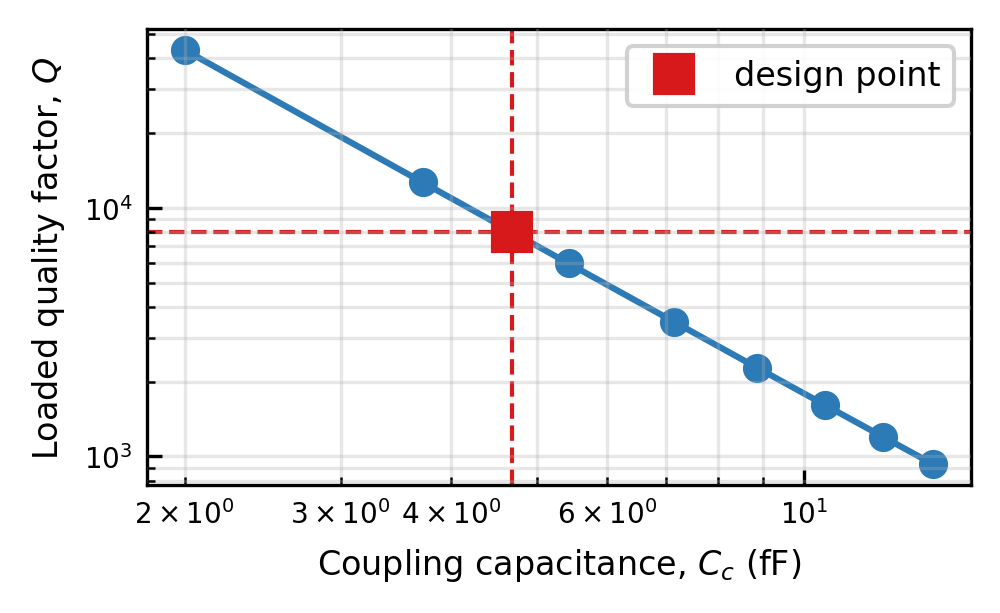

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Coupling capacitance, $C_c$ (fF)', ylabel='Loaded quality factor, $Q$'>)

In [8]:
Cc_star = sl.invert_monotonic(Cc_values, Q_of_Cc, target_Q, log=True)
print("target Q = {}  ->  Cc = {:.2f} fF".format(target_Q, Cc_star * 1e15))

sl.plot_curves(
    Cc_values * 1e15, Q_of_Cc,
    xlabel=sl.LABEL_CC,
    ylabel=sl.axis_label("Loaded quality factor", "Q"),
    fmt="o-",
    color=sl.COLOR_PRIMARY,
    xscale="log", yscale="log",
    hline=target_Q,
    vline=Cc_star * 1e15,
    point=(Cc_star * 1e15, target_Q),
)


## 2. Assemble the design and verify it

We now have a candidate $(d^\star, C_c^\star)$. Build it, measure $f_0$ and
$\kappa$, and check both targets at once with a full readout report.


In [9]:
f0, kappa = sl.extract_f0_kappa(cpw, d=d_star, Cc=Cc_star)
rp = sl.resonator_readout_params(L_star, C_star, kappa_Hz=kappa)

print(rp.summary())
print()
print("target  f_r = {:.2f} GHz   achieved f0 = {:.3f} GHz   ({:+.1f} %)".format(
    target_f, f0 / 1e9, 100 * (f0 / 1e9 - target_f) / target_f))
print("target  Q   = {:<6d}      achieved Q  = {:.0f}       ({:+.1f} %)".format(
    target_Q, rp.Q, 100 * (rp.Q - target_Q) / target_Q))


Resonator readout parameters
----------------------------
  f_r        =     7.0514 GHz
  Z_r        =      29.74 Ohm
  L          =     0.6712 nH
  C          =   758.9574 fF
  V_zpf      =      1.754 uV
  I_zpf      =     58.995 nA
  kappa/2pi  =     0.8817 MHz
  Q (loaded) =       7998
  tau_photon =      180.5 ns

target  f_r = 7.00 GHz   achieved f0 = 7.008 GHz   (+0.1 %)
target  Q   = 8000        achieved Q  = 7998       (-0.0 %)


## 3. Bundle it into a reusable design function

The two inversions compose into `sl.design_resonator`, which runs a short length
sweep and a short coupling sweep, interpolates each, and returns the geometry
plus the achieved parameters.


In [10]:
for tf, tQ in [(9.0, 2000), (7.5, 10000)]:
    d, Cc, f0_GHz, rp = sl.design_resonator(
        tf, tQ, cpw, freq=freq, model=MODEL,
    )
    print("spec: f_r={:.1f} GHz, Q={:<6d}  ->  d={:.2f} mm, Cc={:.2f} fF"
          "   (achieved f0={:.2f} GHz, Q={:.0f})".format(
              tf, tQ, d * 1e3, Cc * 1e15, f0_GHz, rp.Q))


spec: f_r=9.0 GHz, Q=2000    ->  d=6.52 mm, Cc=7.36 fF   (achieved f0=8.96 GHz, Q=1999)


spec: f_r=7.5 GHz, Q=10000   ->  d=7.85 mm, Cc=3.91 fF   (achieved f0=7.51 GHz, Q=9999)
